# Model Evaluation and Cross-Validation

## Objective

Evaluate the baseline machine learning models using cross-validation and held-out test data.

The goal is to determine whether the strong performance observed during baseline modeling is reliable and whether the models show signs of overfitting.

## Evaluation Strategy

The following approaches will be used:

- 5-fold cross-validation on the training dataset
- Evaluation on the held-out test dataset
- Comparison using MAE, RMSE, and R²
- Actual vs predicted visualization
- Comparison between training/cross-validation performance and test performance

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("Training and testing datasets loaded successfully.")

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training and testing datasets loaded successfully.

X_train shape: (299, 27)
X_test shape: (75, 27)
y_train shape: (299, 1)
y_test shape: (75, 1)


In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (299,)
y_test shape: (75,)


In [4]:
models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

print("Models defined:")
for name in models:
    print("-", name)

Models defined:
- Dummy Regressor
- Linear Regression
- Ridge Regression
- Random Forest


In [5]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation configured.")


5-fold cross-validation configured.


In [6]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=True
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean(),
        "Train R²": scores["train_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,CV MAE,CV RMSE,CV R²,Train R²
0,Dummy Regressor,1.032734,1.180049,-0.001889,0.000000
1,Linear Regression,0.156670,0.268957,0.946291,0.965715
2,Ridge Regression,0.159571,0.262043,0.949360,0.964321
3,Random Forest,0.051321,0.160049,0.979606,0.995647


In [7]:
cv_results_df.round(4)

,Model,CV MAE,CV RMSE,CV R²,Train R²
0,Dummy Regressor,1.0327,1.180,-0.0019,0.0000
1,Linear Regression,0.1567,0.269,0.9463,0.9657
2,Ridge Regression,0.1596,0.262,0.9494,0.9643
3,Random Forest,0.0513,0.160,0.9796,0.9956


In [8]:
best_cv_model = cv_results_df.loc[
    cv_results_df["CV R²"].idxmax()
]

print("Best model based on cross-validation R²:")
print(best_cv_model)

Best model based on cross-validation R²:
Model       Random Forest
CV MAE           0.051321
CV RMSE          0.160049
CV R²            0.979606
Train R²         0.995647
Name: 3, dtype: object


In [9]:
best_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [10]:
y_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5
test_r2 = r2_score(y_test, y_pred)

print("Random Forest Test Performance")
print("--------------------------------")
print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²:   {test_r2:.4f}")

Random Forest Test Performance
--------------------------------
MAE:  0.0391
RMSE: 0.1338
R²:   0.9881


In [11]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Cross-Validation": [
        cv_results_df.loc[
            cv_results_df["Model"] == "Random Forest", "CV MAE"
        ].iloc[0],

        cv_results_df.loc[
            cv_results_df["Model"] == "Random Forest", "CV RMSE"
        ].iloc[0],

        cv_results_df.loc[
            cv_results_df["Model"] == "Random Forest", "CV R²"
        ].iloc[0]
    ],
    "Test Set": [
        test_mae,
        test_rmse,
        test_r2
    ]
})

comparison.round(4)

,Metric,Cross-Validation,Test Set
0,MAE,0.0513,0.0391
1,RMSE,0.1600,0.1338
2,R²,0.9796,0.9881


In [12]:
rf_cv = cv_results_df[
    cv_results_df["Model"] == "Random Forest"
].iloc[0]

print("Random Forest evaluation")
print("------------------------")
print(f"Mean training R²:      {rf_cv['Train R²']:.4f}")
print(f"Mean CV R²:            {rf_cv['CV R²']:.4f}")
print(f"Held-out test R²:      {test_r2:.4f}")

r2_gap = rf_cv["Train R²"] - rf_cv["CV R²"]

print(f"\nTraining-CV R² gap:    {r2_gap:.4f}")

Random Forest evaluation
------------------------
Mean training R²:      0.9956
Mean CV R²:            0.9796
Held-out test R²:      0.9881

Training-CV R² gap:    0.0160


## Overfitting Check

The Random Forest model's training R², cross-validation R², and held-out test R² were compared to identify potential overfitting.

A large difference between training performance and validation/test performance would suggest that the model may be overfitting the training data.

The cross-validation results provide a more reliable estimate of how the model may perform on unseen data because the model is evaluated across multiple training and validation splits.

The final interpretation should be based on the actual values produced above rather than assuming that high test performance alone guarantees good generalization.

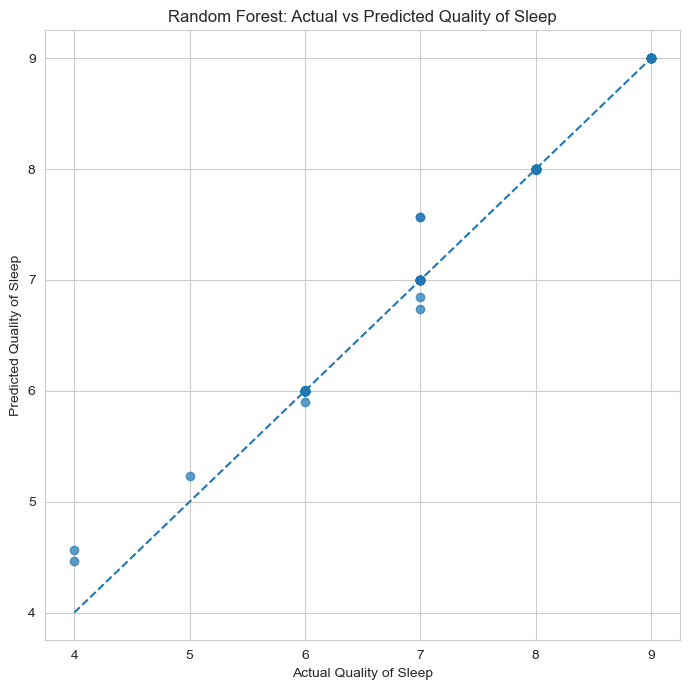

In [13]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Quality of Sleep")
plt.ylabel("Predicted Quality of Sleep")
plt.title("Random Forest: Actual vs Predicted Quality of Sleep")

plt.tight_layout()

plt.show()

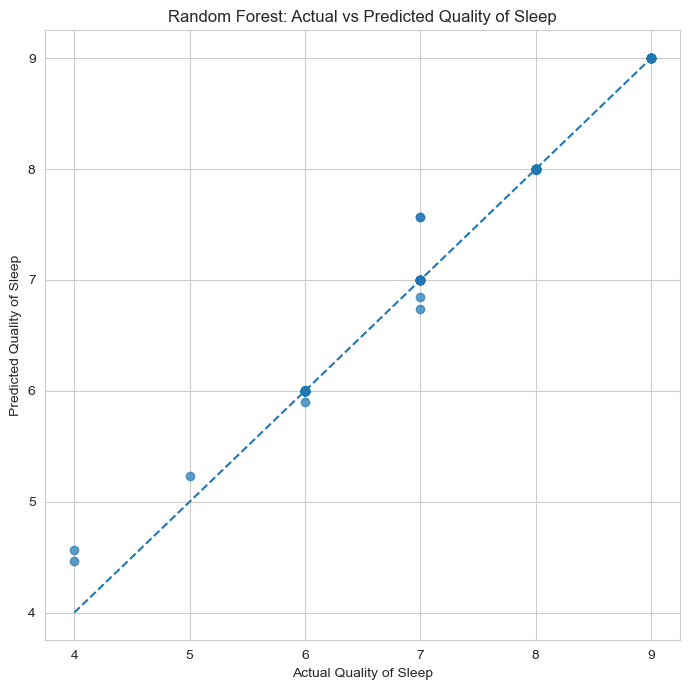

Figure saved successfully.


In [14]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Quality of Sleep")
plt.ylabel("Predicted Quality of Sleep")
plt.title("Random Forest: Actual vs Predicted Quality of Sleep")

plt.tight_layout()

plt.savefig(
    "../figures/random_forest_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

In [15]:
cv_results_df.to_csv(
    "../reports/cross_validation_results.csv",
    index=False
)

comparison.to_csv(
    "../reports/random_forest_cv_vs_test.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [16]:
print("Day 7 Model Evaluation Summary")
print("=" * 40)

print(f"Best CV model: {best_cv_model['Model']}")
print(f"Random Forest CV R²: {rf_cv['CV R²']:.4f}")
print(f"Random Forest Test R²: {test_r2:.4f}")
print(f"Random Forest Test MAE: {test_mae:.4f}")
print(f"Random Forest Test RMSE: {test_rmse:.4f}")

print("\nDay 7 evaluation completed successfully.")

Day 7 Model Evaluation Summary
Best CV model: Random Forest
Random Forest CV R²: 0.9796
Random Forest Test R²: 0.9881
Random Forest Test MAE: 0.0391
Random Forest Test RMSE: 0.1338

Day 7 evaluation completed successfully.
